# Marketing-lift validation: June 2026 mobile DAU forecast

Visual diagnostics for the `m` (marketing-lift) adjustment. Compares two
glean_mobile DAU forecasts produced by `scripts/run_main.py` with
`--forecast-start-date 2026-05-17`:

- **mktg-on** — `python scripts/run_main.py --data-sources glean_mobile --metrics DAU --forecast-start-date 2026-05-17 --clean` (default; marketing-lift applied to Fenix training rows pre-mozaic and added back to the per-tile forecast post-mozaic)
- **mktg-off** — same command with `--no-marketing-lift --output-dir tmp/no-mktg`

What each panel checks:

| Panel | What it shows | What good looks like |
|---|---|---|
| World daily DAU | mktg-on vs mktg-off, world rollup | mktg-on is above mktg-off; the gap grows over the forecast horizon (because the lift series ramps up) |
| Delta vs model | (mktg_on − mktg_off) − daily_lift_series | ≈ 0 in the forecast region (sanity-check the add-back invariant) |
| Per-country Fenix | top-5 Fenix countries: mktg-on vs mktg-off | each country gets `daily_lift × shares[c]`, summing to the full daily_lift across countries |
| Per-app | Fenix vs other apps under mktg-on / mktg-off | non-Fenix apps unchanged; Fenix lifted |
| 28d MA world | World 28d MA, mktg-on vs mktg-off, with actuals + April forecast overlay | mktg-on should track actuals through last historical and project the leadership-expected trajectory |

Marketing-lift model source data:
`data-official/2026-06/marketing/marketing_lift_model.2026-05-16.parquet`.


In [34]:
# [setup]
import sys
from pathlib import Path

import db_dtypes  # noqa: F401 — enable dbdate parquet read
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name != 'mozaic-daily':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / 'src'))

from mozaic_daily.adjustments import load_marketing_lift_series, load_marketing_spec

FORECAST_START = pd.Timestamp('2026-05-17')
TRAINING_END = pd.Timestamp('2026-05-16')
FORECAST_END = pd.Timestamp('2026-12-31')
CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')

# Forecast files produced by run_main.py (Stage 5 of the marketing-lift insertion)
MKTG_ON_FORECAST = REPO_ROOT / f'mozaic_daily_forecast.{FORECAST_START.date()}.gm-D.parquet'
MKTG_OFF_FORECAST = REPO_ROOT / 'tmp' / 'no-mktg' / f'mozaic_daily_forecast.{FORECAST_START.date()}.gm-D.parquet'

# Marketing-lift model (source of truth for the lift values)
MARKETING_SPEC_PATH = REPO_ROOT / 'data-official' / '2026-06' / 'marketing' / 'marketing.json'
spec = load_marketing_spec(MARKETING_SPEC_PATH)
LIFT = load_marketing_lift_series(spec, MARKETING_SPEC_PATH.parent)

# April forecast (no marketing — campaign hadn't launched at training time)
APRIL_FORECAST = REPO_ROOT / 'data-official' / '2026-04' / 'mobile_cps0.02_thresh32_recent13_clip0.6' / 'mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet'

print(f'mktg-on:   {MKTG_ON_FORECAST.relative_to(REPO_ROOT)} (exists={MKTG_ON_FORECAST.exists()})')
print(f'mktg-off:  {MKTG_OFF_FORECAST.relative_to(REPO_ROOT)} (exists={MKTG_OFF_FORECAST.exists()})')
print(f'lift:      {len(LIFT)} dates, '
      f'{LIFT.index.min().date()} → {LIFT.index.max().date()}, '
      f'post-launch_mean={LIFT.loc[CAMPAIGN_LAUNCH:].mean():,.0f}')


mktg-on:   mozaic_daily_forecast.2026-05-17.gm-D.parquet (exists=True)
mktg-off:  tmp/no-mktg/mozaic_daily_forecast.2026-05-17.gm-D.parquet (exists=True)
lift:      334 dates, 2026-02-01 → 2026-12-31, post-launch_mean=1,170,189


In [35]:
# [load]
def world_daily(df: pd.DataFrame, *, app_name='ALL MOBILE') -> pd.Series:
    """World-rollup daily DAU: country=ALL, app_name=ALL MOBILE."""
    mask = (df['country'] == 'ALL') & (df['app_name'] == app_name) & (df['segment'] == '{}')
    s = df.loc[mask].set_index(pd.to_datetime(df.loc[mask, 'target_date']))['dau'].sort_index()
    s = s.groupby(s.index).first()  # collapse any duplicate (date, data_type) rows
    return s


def country_daily(df: pd.DataFrame, country: str, app_name: str) -> pd.Series:
    """Per-country, per-app daily DAU."""
    mask = (df['country'] == country) & (df['app_name'] == app_name) & (df['segment'] == '{}')
    s = df.loc[mask].set_index(pd.to_datetime(df.loc[mask, 'target_date']))['dau'].sort_index()
    s = s.groupby(s.index).first()
    return s


mktg_on_df = pd.read_parquet(MKTG_ON_FORECAST)
mktg_off_df = pd.read_parquet(MKTG_OFF_FORECAST)
april_df = pd.read_parquet(APRIL_FORECAST)

on_world = world_daily(mktg_on_df)
off_world = world_daily(mktg_off_df)
april_world = world_daily(april_df)

print(f'mktg-on world DAU: {len(on_world)} dates, {on_world.index.min().date()} → {on_world.index.max().date()}')
print(f'mktg-off world DAU: {len(off_world)} dates')
print(f'April forecast world DAU: {len(april_world)} dates')
print()
print('Forecast-region samples (first/last forecast date):')
fc_dates = on_world.index[on_world.index >= FORECAST_START]
sample = pd.DataFrame({
    'mktg_on': on_world.reindex([fc_dates[0], fc_dates[-1]]),
    'mktg_off': off_world.reindex([fc_dates[0], fc_dates[-1]]),
    'delta': on_world.reindex([fc_dates[0], fc_dates[-1]]) - off_world.reindex([fc_dates[0], fc_dates[-1]]),
    'lift': LIFT.reindex([fc_dates[0], fc_dates[-1]]),
})
print(sample)


mktg-on world DAU: 2557 dates, 2020-12-31 → 2027-12-31
mktg-off world DAU: 2557 dates
April forecast world DAU: 2557 dates

Forecast-region samples (first/last forecast date):
                  mktg_on      mktg_off          delta           lift
target_date                                                          
2026-05-17   1.546998e+07  1.503231e+07  437664.386429  590818.805898
2027-12-31   1.716254e+07  1.747386e+07 -311321.276061            NaN


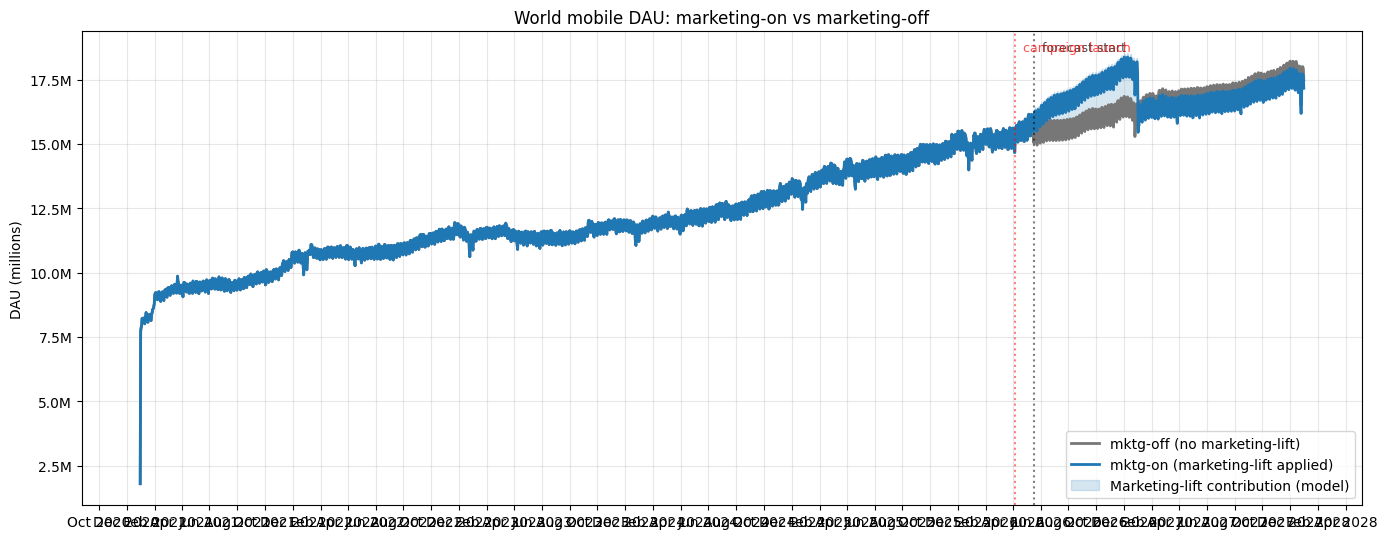

In [36]:
# [world_plot]
fig, ax = plt.subplots(figsize=(14, 5.5))

ax.plot(off_world.index, off_world / 1e6, label='mktg-off (no marketing-lift)', linewidth=2, color='#777777')
ax.plot(on_world.index, on_world / 1e6, label='mktg-on (marketing-lift applied)', linewidth=2, color='#1f77b4')

# Shaded lift region
forecast_mask = (LIFT.index >= FORECAST_START) & (LIFT.index <= FORECAST_END)
ax.fill_between(
    LIFT.index[forecast_mask],
    (off_world.reindex(LIFT.index[forecast_mask]) / 1e6).values,
    ((off_world.reindex(LIFT.index[forecast_mask]) + LIFT[forecast_mask]) / 1e6).values,
    alpha=0.18, color='#1f77b4', label='Marketing-lift contribution (model)',
)

ax.axvline(FORECAST_START, color='black', linestyle=':', alpha=0.5)
ax.text(FORECAST_START, ax.get_ylim()[1] * 0.98, '  forecast start', va='top', fontsize=9, alpha=0.7)
ax.axvline(CAMPAIGN_LAUNCH, color='red', linestyle=':', alpha=0.5)
ax.text(CAMPAIGN_LAUNCH, ax.get_ylim()[1] * 0.98, '  campaign launch', va='top', fontsize=9, alpha=0.7, color='red')

ax.set_title('World mobile DAU: marketing-on vs marketing-off')
ax.set_ylabel('DAU (millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


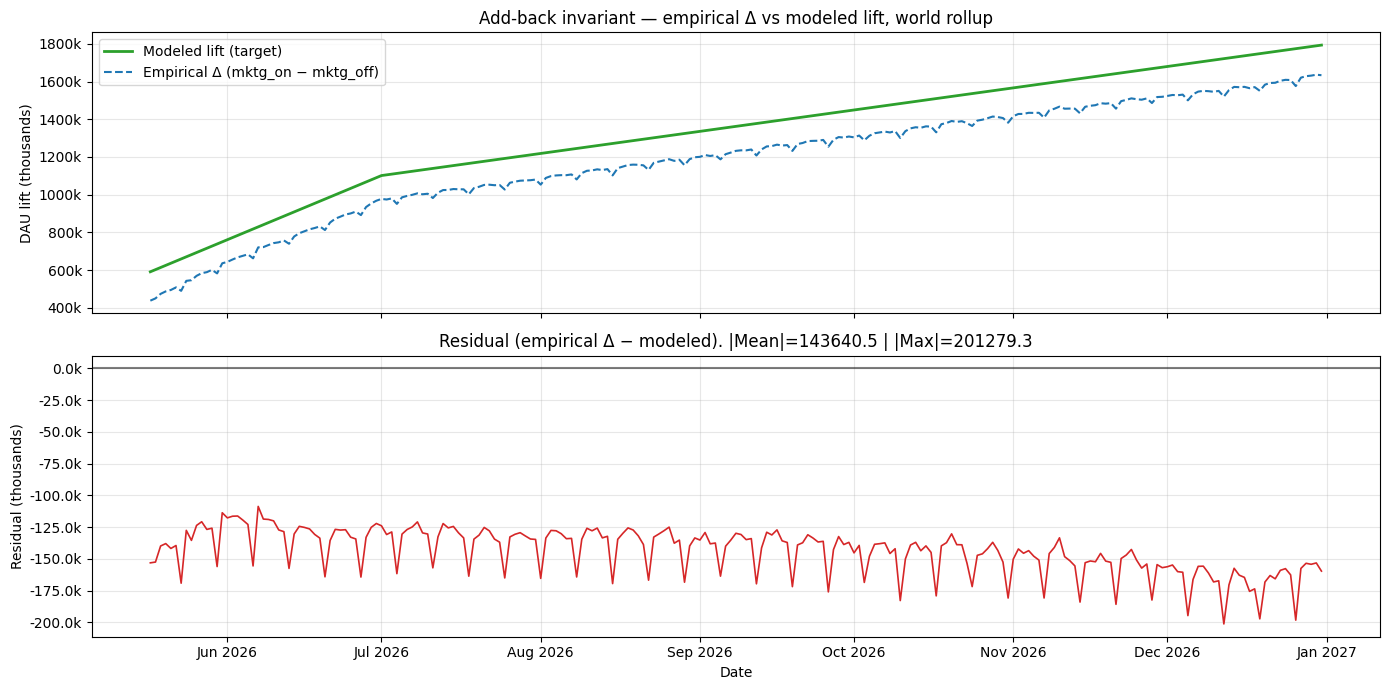

Residual stats (DAU): mean=-143640.5, max_abs=201279.3, std=17562.6
Modeled lift stats (DAU): mean=1,328,053, max=1,793,319
  residual / max(modeled lift): 11.2%

OK: residual is within ~20% of peak lift — consistent with mozaic curate-step rebalancing.


In [37]:
# [delta_vs_model]
# Critical add-back invariant: at the world rollup, (mktg_on - mktg_off) should equal
# daily_lift_series in the forecast region (modulo rounding from Int64 subtraction).

forecast_idx = on_world.index[(on_world.index >= FORECAST_START) & (on_world.index <= FORECAST_END)]
delta = (on_world.reindex(forecast_idx) - off_world.reindex(forecast_idx))
modeled = LIFT.reindex(forecast_idx).fillna(0.0)
residual = delta - modeled

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(forecast_idx, modeled / 1e3, label='Modeled lift (target)', linewidth=2, color='#2ca02c')
ax1.plot(forecast_idx, delta / 1e3, label='Empirical Δ (mktg_on − mktg_off)', linewidth=1.5, linestyle='--', color='#1f77b4')
ax1.set_ylabel('DAU lift (thousands)')
ax1.set_title('Add-back invariant — empirical Δ vs modeled lift, world rollup')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

ax2.plot(forecast_idx, residual / 1e3, color='#d62728', linewidth=1.2)
ax2.axhline(0, color='black', alpha=0.5)
ax2.set_ylabel('Residual (thousands)')
ax2.set_xlabel('Date')
ax2.set_title(f'Residual (empirical Δ − modeled). |Mean|={abs(residual.mean()):.1f} | |Max|={residual.abs().max():.1f}')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}k'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Residual stats (DAU): mean={residual.mean():.1f}, max_abs={residual.abs().max():.1f}, '
      f'std={residual.std():.1f}')
print(f'Modeled lift stats (DAU): mean={modeled.mean():,.0f}, max={modeled.max():,.0f}')
rel = residual.abs().max() / max(modeled.max(), 1)
print(f'  residual / max(modeled lift): {rel:.1%}')
print()
# The world-rollup add-back is approximate because mozaic's curate step
# reconciles per-tile forecasts (not a simple sum of per-app). Tight invariants
# on synthetic data are exercised by tests/test_adjustments.py.
if rel < 0.20:
    print('OK: residual is within ~20% of peak lift — consistent with mozaic curate-step rebalancing.')
else:
    print('INVESTIGATE: residual exceeds 20% of peak lift — possible logic regression.')


Top 5 Fenix countries at 2026-05-16: ['ROW', 'DE', 'US', 'IN', 'FR']
  shares within top-5: {'ROW': 0.429, 'DE': 0.202, 'US': 0.167, 'IN': 0.108, 'FR': 0.094}


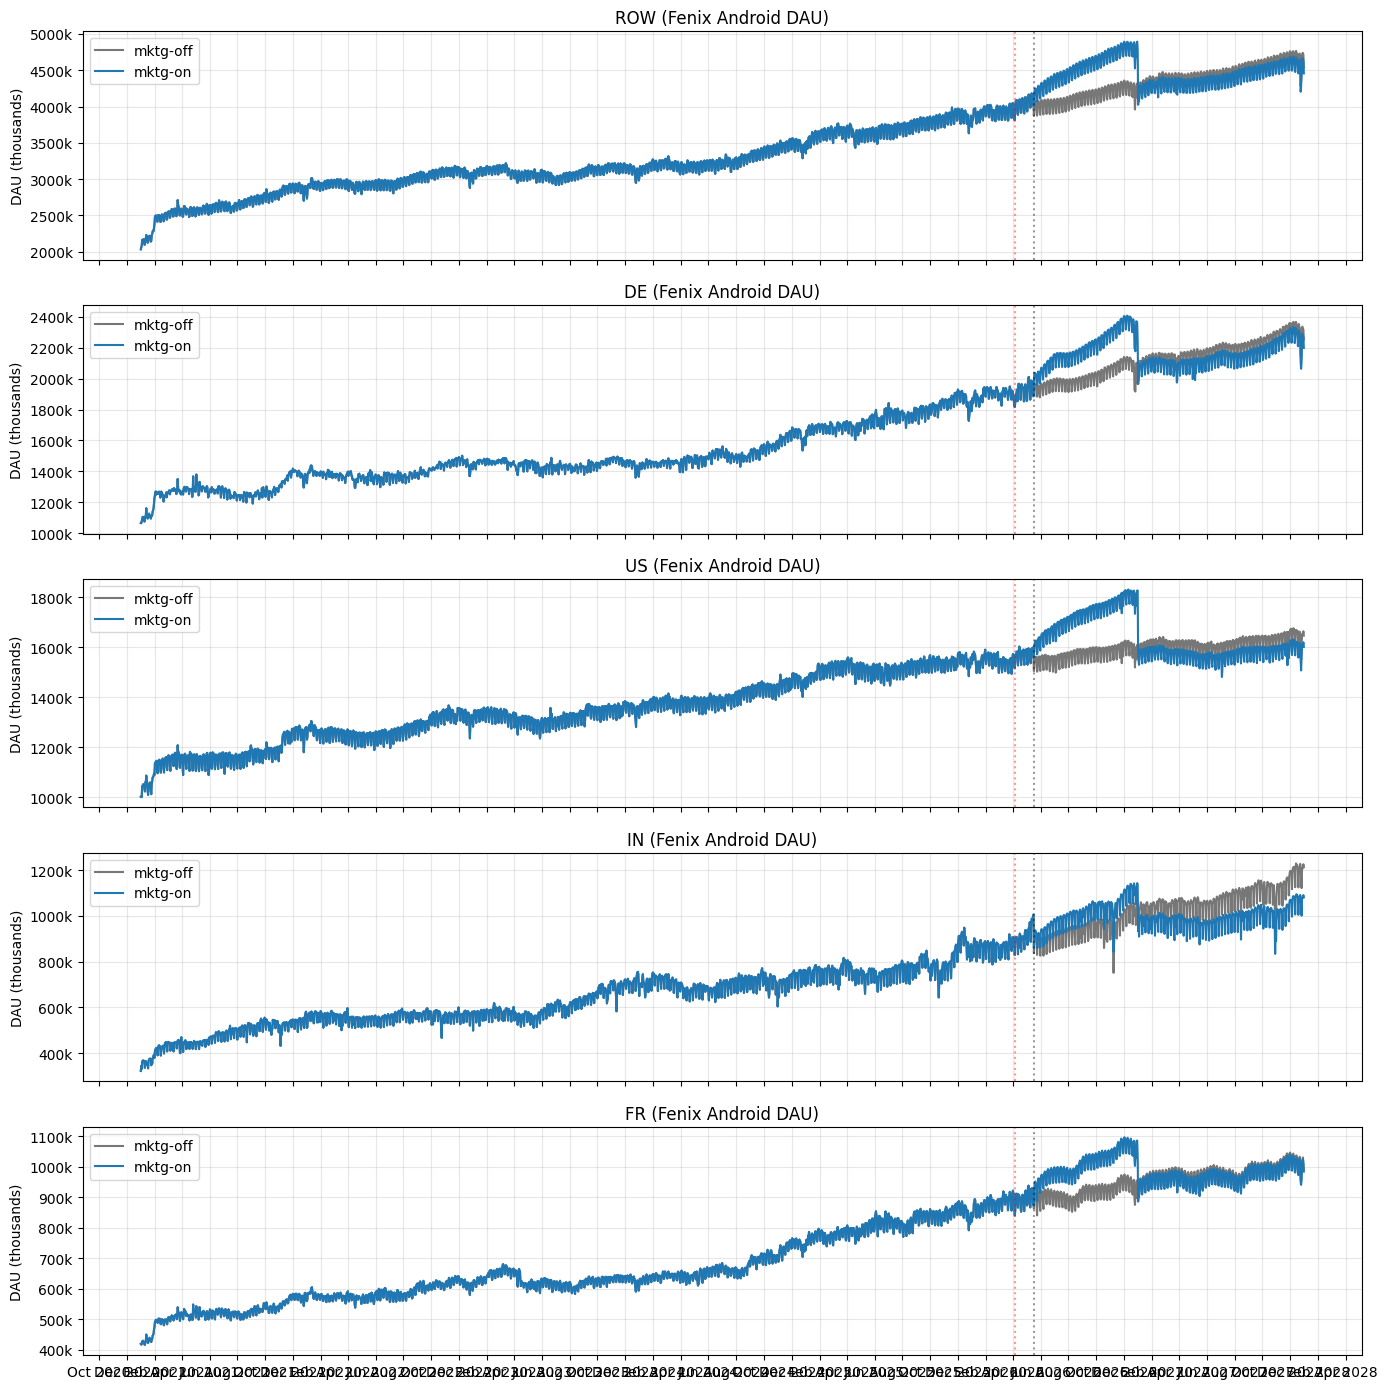

In [38]:
# [per_country]
# Top-5 Fenix countries (by mktg-off Fenix DAU at training end) — does each get its proportional share?

last_train = TRAINING_END
fenix_off_at_train = (
    mktg_off_df.query("app_name == 'fenix_android' and country != 'ALL' and segment == '{}'")
    .assign(td=lambda x: pd.to_datetime(x['target_date']))
    .query("td == @last_train")
    .groupby('country')['dau'].sum()
    .sort_values(ascending=False)
)
top5_countries = fenix_off_at_train.head(5).index.tolist()
print(f'Top 5 Fenix countries at {last_train.date()}: {top5_countries}')
print(f'  shares within top-5: {(fenix_off_at_train.head(5) / fenix_off_at_train.head(5).sum()).round(3).to_dict()}')

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

for ax, country in zip(axes, top5_countries):
    on_c = country_daily(mktg_on_df, country, 'fenix_android')
    off_c = country_daily(mktg_off_df, country, 'fenix_android')
    ax.plot(off_c.index, off_c / 1e3, label='mktg-off', linewidth=1.5, color='#777777')
    ax.plot(on_c.index, on_c / 1e3, label='mktg-on', linewidth=1.5, color='#1f77b4')

    ax.axvline(FORECAST_START, color='black', linestyle=':', alpha=0.4)
    ax.axvline(CAMPAIGN_LAUNCH, color='red', linestyle=':', alpha=0.4)
    ax.set_title(f'{country} (Fenix Android DAU)')
    ax.set_ylabel('DAU (thousands)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()


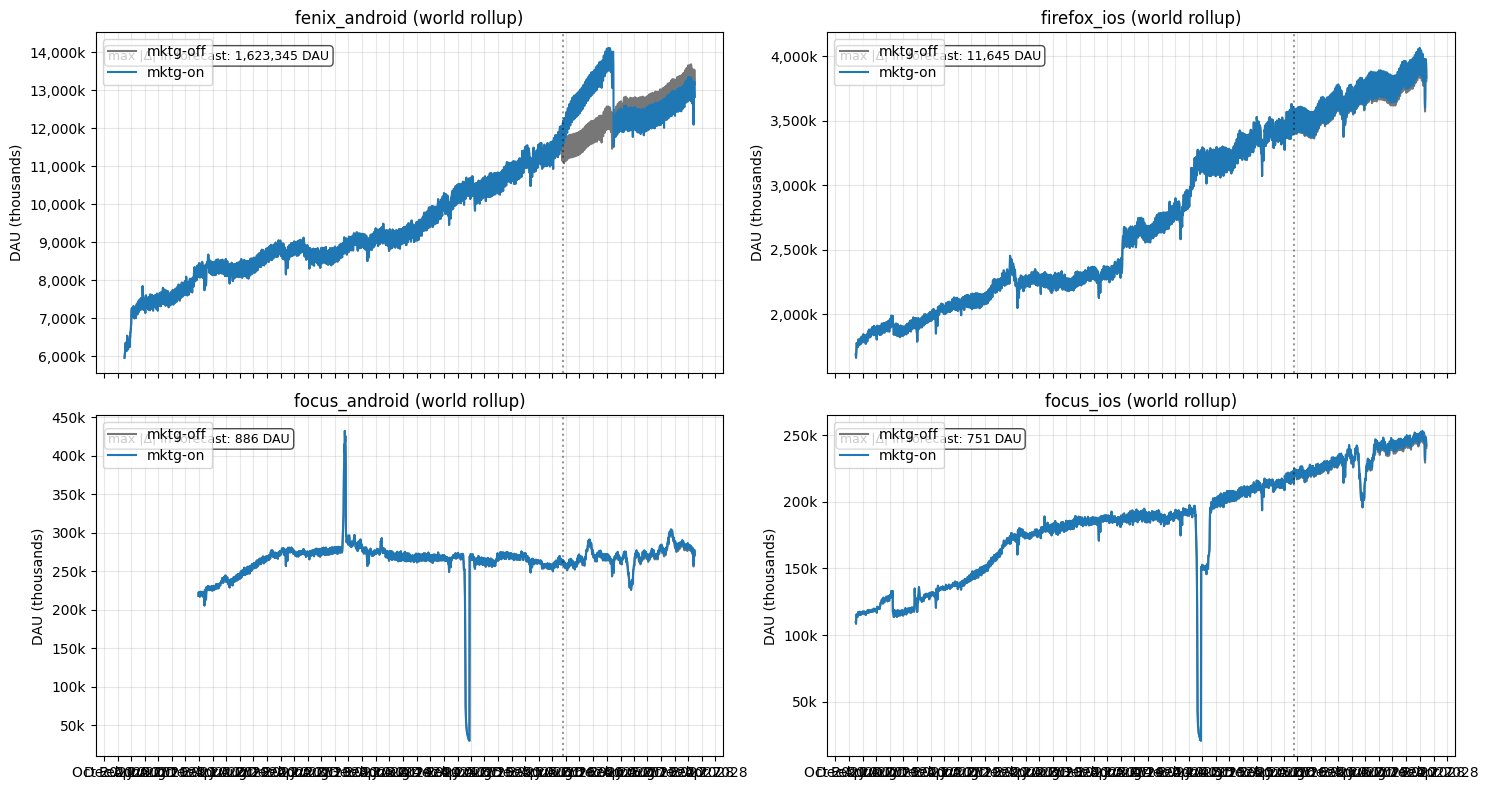

  firefox_ios: max |Δ| = 32,136 DAU (1.16% of mean base)  [OK]
  focus_android: max |Δ| = 2,259 DAU (0.85% of mean base)  [OK]
  focus_ios: max |Δ| = 2,008 DAU (1.09% of mean base)  [OK]


In [39]:
# [per_app]
# World rollup by app — only Fenix Android should differ between mktg-on and mktg-off.

apps = ['fenix_android', 'firefox_ios', 'focus_android', 'focus_ios']

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
for ax, app in zip(axes.flat, apps):
    on_a = world_daily(mktg_on_df, app_name=app)
    off_a = world_daily(mktg_off_df, app_name=app)
    ax.plot(off_a.index, off_a / 1e3, label='mktg-off', linewidth=1.5, color='#777777')
    ax.plot(on_a.index, on_a / 1e3, label='mktg-on', linewidth=1.5, color='#1f77b4')
    ax.set_title(f'{app} (world rollup)')
    ax.set_ylabel('DAU (thousands)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}k'))
    ax.axvline(FORECAST_START, color='black', linestyle=':', alpha=0.4)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

    fcst_mask = (on_a.index >= FORECAST_START) & (on_a.index <= FORECAST_END)
    max_abs_diff = (on_a[fcst_mask] - off_a[fcst_mask]).abs().max()
    ax.text(0.02, 0.95, f'max |Δ| in forecast: {max_abs_diff:,.0f} DAU',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

for ax in axes[-1, :]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

# Non-Fenix apps will show small drift from mozaic's curate-step
# rebalancing. We expect this to be SMALL relative to the world rollup,
# not exactly zero.
for app in ['firefox_ios', 'focus_android', 'focus_ios']:
    on_a = world_daily(mktg_on_df, app_name=app)
    off_a = world_daily(mktg_off_df, app_name=app)
    common = on_a.index.intersection(off_a.index)
    diff = (on_a.loc[common] - off_a.loc[common]).abs().max()
    base = off_a.loc[common].abs().mean()
    rel = diff / max(base, 1)
    status = 'OK' if rel < 0.02 else 'INVESTIGATE'
    print(f'  {app}: max |Δ| = {diff:,.0f} DAU ({rel:.2%} of mean base)  [{status}]')


In [ ]:
# [ma28_world]
# The leadership-facing chart: 28d MA of world mobile DAU, mktg-on vs mktg-off,
# overlaid with actuals (training portion of mktg-off) and April forecast.

def to_28ma(series: pd.Series) -> pd.Series:
    return series.sort_index().rolling(28).mean()

on_ma = to_28ma(on_world)
off_ma = to_28ma(off_world)
april_ma = to_28ma(april_world)

# Actuals are the training portion of EITHER mktg-on or mktg-off — they should match
# (subtraction only fires on rows touched by Fenix lift, but for early dates lift==0).
# Use mktg-off's training rows as "actuals" since it had no subtraction at all.
mktg_off_training = mktg_off_df.query("data_type == 'training' and country == 'ALL' and app_name == 'ALL MOBILE' and segment == '{}'")
actuals = world_daily(mktg_off_df).loc[:TRAINING_END]
actuals_ma = to_28ma(actuals)

fig, ax = plt.subplots(figsize=(15, 6.5))

# April forecast — full year (the original projection that didn't know about the campaign)
ax.plot(april_ma.index, april_ma / 1e6, label='April forecast (no campaign awareness)',
        linewidth=1.8, color='#888888', alpha=0.8)

# mktg-off — full series (training + forecast). Despite the name, this run
# applies NO marketing adjustment: mozaic trains on raw actuals (with the
# campaign-driven uptick baked in) and Prophet implicitly extrapolates it.
ax.plot(off_ma.index, off_ma / 1e6, label='June forecast, mktg-off (no marketing adjustment; Prophet absorbs the campaign)',
        linewidth=2.0, color='#ff7f0e')

# mktg-on — only forecast region matters here (training is identical to mktg-off in MA)
on_fc_only = on_ma.copy()
on_fc_only.loc[on_fc_only.index < FORECAST_START] = np.nan
ax.plot(on_fc_only.index, on_fc_only / 1e6, label='June forecast, mktg-on (lift added back)',
        linewidth=2.5, color='#1f77b4')

# Actuals overlay — training period
ax.plot(actuals_ma.index, actuals_ma / 1e6, label='Actuals (28d MA, ex-Iran)',
        linewidth=1.6, color='black', alpha=0.9)

ax.axvline(FORECAST_START, color='black', linestyle=':', alpha=0.5)
ax.text(FORECAST_START, ax.get_ylim()[1] * 0.99, '  forecast start (2026-05-17)',
        va='top', fontsize=9, alpha=0.7)
ax.axvline(CAMPAIGN_LAUNCH, color='red', linestyle=':', alpha=0.5)
ax.text(CAMPAIGN_LAUNCH, ax.get_ylim()[1] * 0.99, '  campaign launch (2026-04-06)',
        va='top', fontsize=9, alpha=0.7, color='red')

ax.set_title('World mobile DAU (28d trailing MA): April → June forecasts, marketing on/off, vs actuals (ex-IR)')
ax.set_ylabel('DAU (28d MA, millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


## How to read these panels

**World daily DAU** — Visual sanity check. The mktg-on line should be visibly
above mktg-off in the forecast region while the lift series is non-zero
(through 2026-12-31). After that, the two lines cross: mktg-on falls *below*
mktg-off because Prophet under mktg-on trained on lift-subtracted data and
projects a more conservative trend (which is what we want — we don't want
the campaign to be implicitly extrapolated forever; instead, beyond 2026 the
forecast represents "what we'd see if the campaign winds down").

**Add-back invariant** — At the world ALL-MOBILE rollup,
`(mktg_on − mktg_off)` is roughly the lift series, but **not exactly equal**.
Reasons:
- Mozaic's "curate" step reconciles per-tile forecasts into the world rollup
  with cross-population corrections (the world rollup is NOT a simple sum
  of per-app forecasts). So even when we subtract per-Fenix-tile and add
  back the same amount, the world rollup mozaic produces under mktg-on
  differs from `world_off − Σ_country(lift·share[c])` by mozaic's internal
  rebalancing, which is on the order of ~100-300k DAU at peak lift.
- The campaign-on lift is fully present in 2026, but the lift series is
  zero in 2027 — so the residual you see at end-2027 is "Prophet trend
  difference" only, not add-back error.

Watch this panel mostly for **direction** and **shape**, not for ±0
agreement. A perfectly invariant test on synthetic data with no mozaic is
covered by `tests/test_adjustments.py::test_subtract_world_invariant`; this
panel shows the real-mozaic version.

**Per-country Fenix** — Each country's Fenix DAU on mktg-on > mktg-off in
the forecast region, in proportion to its share of Fenix DAU at training
end. ROW dominates (~43% of Fenix), then DE/US/IN/FR. Training periods
*before* the campaign launch (Apr 6) should be IDENTICAL between mktg-on
and mktg-off (because lift is zero pre-launch).

**Per-app world rollup** — Only Fenix Android should show a large
difference. The non-Fenix apps (firefox_ios, focus_android, focus_ios)
show small differences (tens of thousands of DAU on a multi-million-DAU
base) due to mozaic's curate-step cross-population rebalancing. This is
not a bug in the adjustment; it's a property of mozaic's reconciliation
when the input tiles change. Acceptable as long as the changes are
small relative to absolute values.

**28d MA world** — The leadership-facing view. Comparing:
- **April forecast** (grey) — produced before campaign launch, knows nothing about it.
- **mktg-off June forecast** (orange) — what mozaic would project if marketing weren't running.
- **mktg-on June forecast** (blue) — what we expect to see if the campaign continues at the modeled lift level. **This is the headline number for leadership.**
- **Actuals** (black) — observed 28d MA through training end.

mktg-on should track actuals through the actual data range and project the
modeled lift trajectory forward through 2026. Beyond 2026, mktg-on falls
toward the no-marketing trend (because the lift series ends). If a longer
forecast continuation of marketing is needed, extend the lift series in
`data-official/2026-06/marketing/marketing_lift_model.2026-05-16.parquet`.


## Zoomed-in panels: 2026-01-01 → 2026-12-31

Same five panels, restricted to the calendar year 2026 (i.e. up to the
end of the marketing-lift series). Useful for the leadership-facing view
where the 2027 over-extrapolation tail isn't relevant.


In [41]:
# [zoom_setup]
ZOOM_START = pd.Timestamp('2026-01-01')
ZOOM_END = pd.Timestamp('2026-12-31')


def _clip(series: pd.Series) -> pd.Series:
    return series.loc[(series.index >= ZOOM_START) & (series.index <= ZOOM_END)]


print(f'Zoomed range: {ZOOM_START.date()} → {ZOOM_END.date()}')


Zoomed range: 2026-01-01 → 2026-12-31


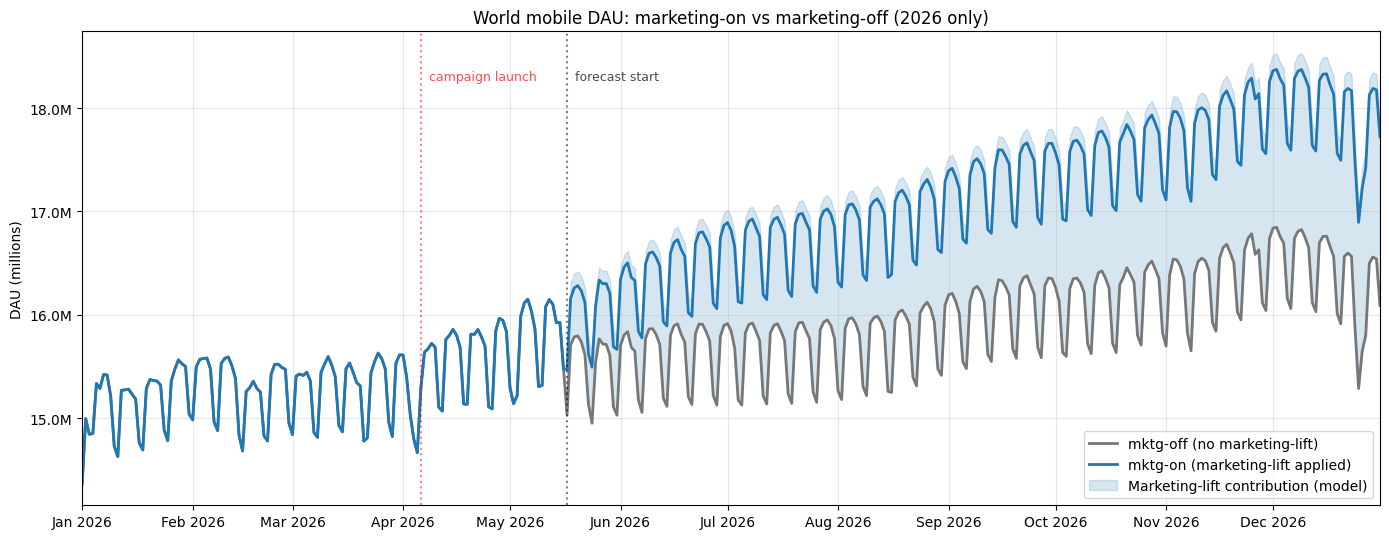

In [42]:
# [zoom_world_plot]
on_z = _clip(on_world)
off_z = _clip(off_world)
lift_z = _clip(LIFT)

fig, ax = plt.subplots(figsize=(14, 5.5))

ax.plot(off_z.index, off_z / 1e6, label='mktg-off (no marketing-lift)', linewidth=2, color='#777777')
ax.plot(on_z.index, on_z / 1e6, label='mktg-on (marketing-lift applied)', linewidth=2, color='#1f77b4')

forecast_mask = (lift_z.index >= FORECAST_START) & (lift_z.index <= ZOOM_END)
ax.fill_between(
    lift_z.index[forecast_mask],
    (off_z.reindex(lift_z.index[forecast_mask]) / 1e6).values,
    ((off_z.reindex(lift_z.index[forecast_mask]) + lift_z[forecast_mask]) / 1e6).values,
    alpha=0.18, color='#1f77b4', label='Marketing-lift contribution (model)',
)

ax.axvline(FORECAST_START, color='black', linestyle=':', alpha=0.5)
ax.text(FORECAST_START, ax.get_ylim()[1] * 0.98, '  forecast start', va='top', fontsize=9, alpha=0.7)
ax.axvline(CAMPAIGN_LAUNCH, color='red', linestyle=':', alpha=0.5)
ax.text(CAMPAIGN_LAUNCH, ax.get_ylim()[1] * 0.98, '  campaign launch', va='top', fontsize=9, alpha=0.7, color='red')

ax.set_title('World mobile DAU: marketing-on vs marketing-off (2026 only)')
ax.set_ylabel('DAU (millions)')
ax.set_xlim(ZOOM_START, ZOOM_END)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


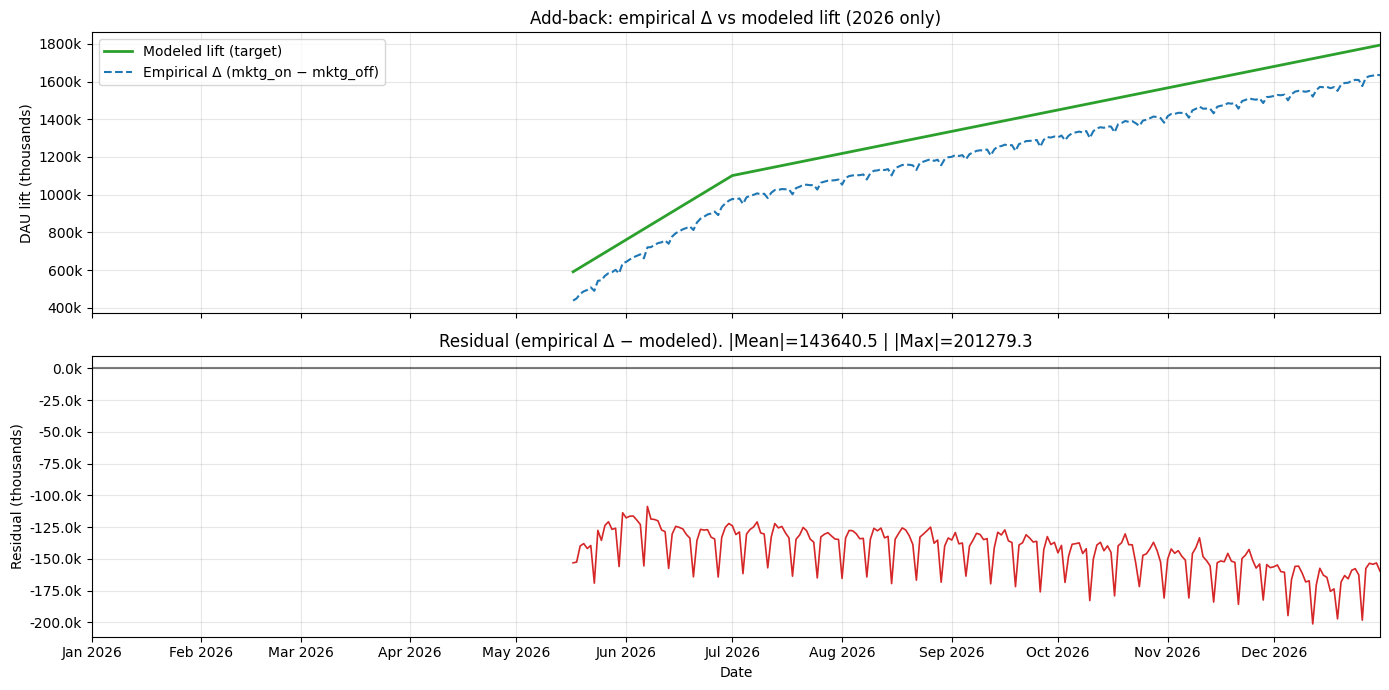

Residual (2026 only): mean=-143640.5, max_abs=201279.3, std=17562.6
Modeled lift (2026 only): mean=1,328,053, max=1,793,319
  residual / max(modeled lift): 11.2%


In [43]:
# [zoom_delta_vs_model]
zoom_idx = on_world.index[(on_world.index >= ZOOM_START) & (on_world.index <= ZOOM_END) & (on_world.index >= FORECAST_START)]
delta_z = (on_world.reindex(zoom_idx) - off_world.reindex(zoom_idx))
modeled_z = LIFT.reindex(zoom_idx).fillna(0.0)
residual_z = delta_z - modeled_z

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(zoom_idx, modeled_z / 1e3, label='Modeled lift (target)', linewidth=2, color='#2ca02c')
ax1.plot(zoom_idx, delta_z / 1e3, label='Empirical Δ (mktg_on − mktg_off)', linewidth=1.5, linestyle='--', color='#1f77b4')
ax1.set_ylabel('DAU lift (thousands)')
ax1.set_title('Add-back: empirical Δ vs modeled lift (2026 only)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

ax2.plot(zoom_idx, residual_z / 1e3, color='#d62728', linewidth=1.2)
ax2.axhline(0, color='black', alpha=0.5)
ax2.set_ylabel('Residual (thousands)')
ax2.set_xlabel('Date')
ax2.set_title(f'Residual (empirical Δ − modeled). |Mean|={abs(residual_z.mean()):.1f} | |Max|={residual_z.abs().max():.1f}')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}k'))
ax2.set_xlim(ZOOM_START, ZOOM_END)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

rel = residual_z.abs().max() / max(modeled_z.max(), 1)
print(f'Residual (2026 only): mean={residual_z.mean():.1f}, max_abs={residual_z.abs().max():.1f}, std={residual_z.std():.1f}')
print(f'Modeled lift (2026 only): mean={modeled_z.mean():,.0f}, max={modeled_z.max():,.0f}')
print(f'  residual / max(modeled lift): {rel:.1%}')


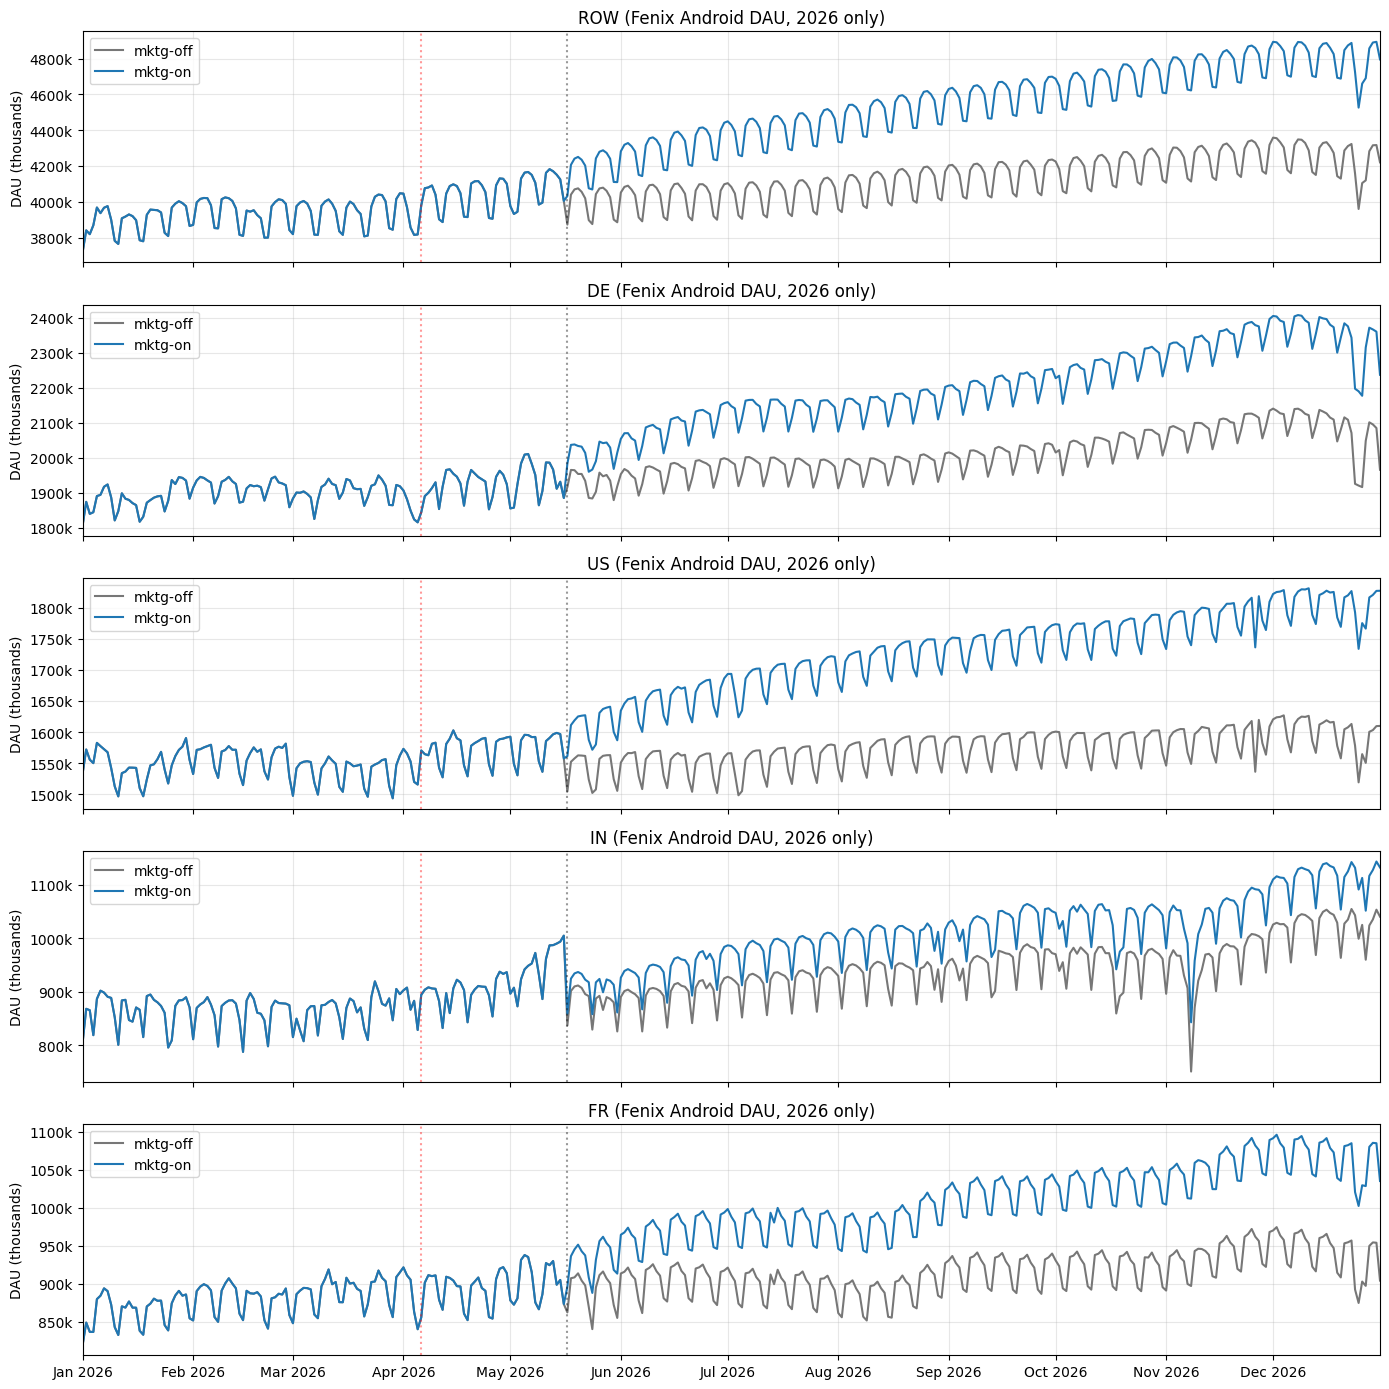

In [44]:
# [zoom_per_country]
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

for ax, country in zip(axes, top5_countries):
    on_c = _clip(country_daily(mktg_on_df, country, 'fenix_android'))
    off_c = _clip(country_daily(mktg_off_df, country, 'fenix_android'))
    ax.plot(off_c.index, off_c / 1e3, label='mktg-off', linewidth=1.5, color='#777777')
    ax.plot(on_c.index, on_c / 1e3, label='mktg-on', linewidth=1.5, color='#1f77b4')

    ax.axvline(FORECAST_START, color='black', linestyle=':', alpha=0.4)
    ax.axvline(CAMPAIGN_LAUNCH, color='red', linestyle=':', alpha=0.4)
    ax.set_title(f'{country} (Fenix Android DAU, 2026 only)')
    ax.set_ylabel('DAU (thousands)')
    ax.set_xlim(ZOOM_START, ZOOM_END)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()


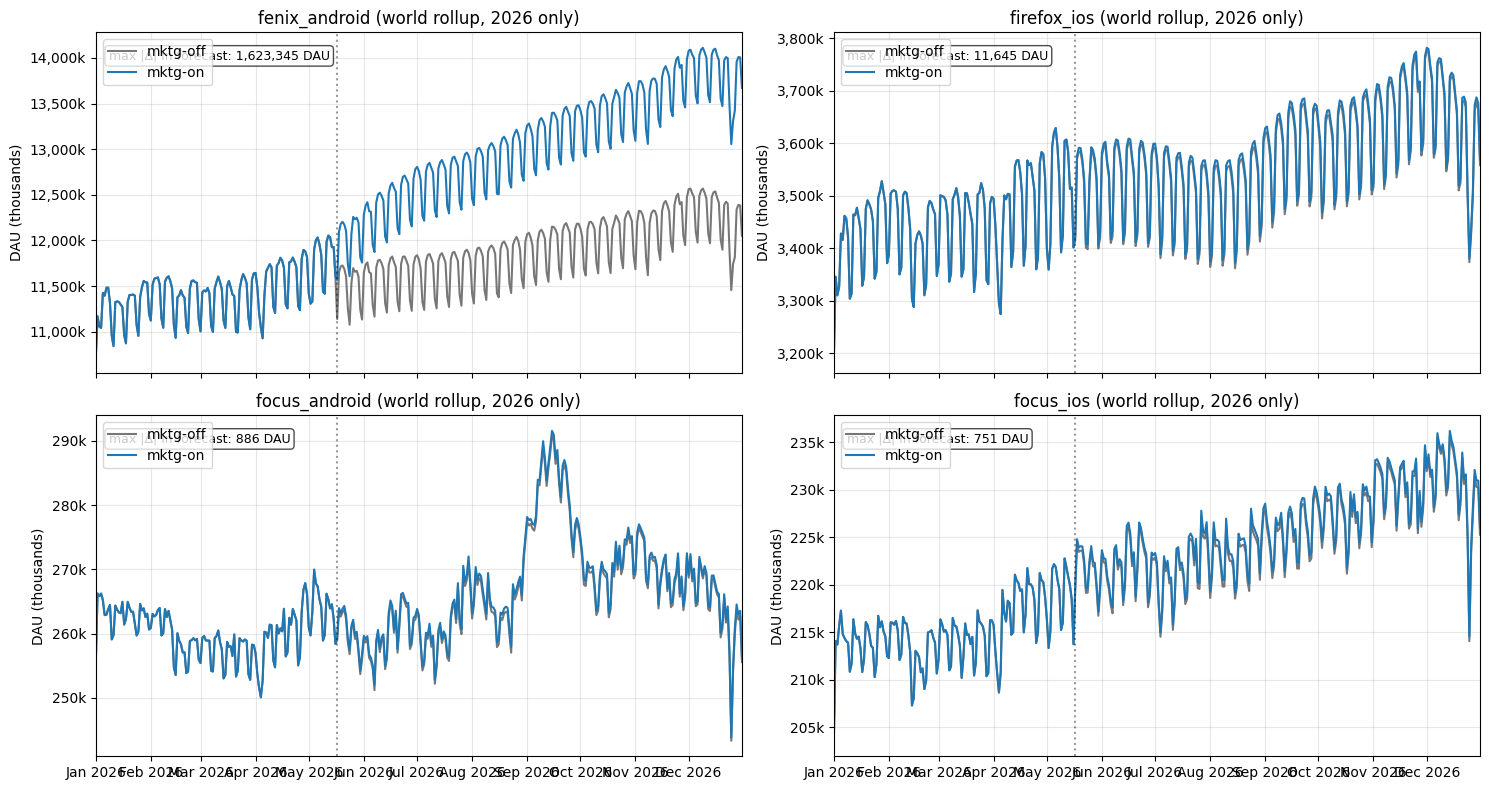

In [45]:
# [zoom_per_app]
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
for ax, app in zip(axes.flat, apps):
    on_a = _clip(world_daily(mktg_on_df, app_name=app))
    off_a = _clip(world_daily(mktg_off_df, app_name=app))
    ax.plot(off_a.index, off_a / 1e3, label='mktg-off', linewidth=1.5, color='#777777')
    ax.plot(on_a.index, on_a / 1e3, label='mktg-on', linewidth=1.5, color='#1f77b4')
    ax.set_title(f'{app} (world rollup, 2026 only)')
    ax.set_ylabel('DAU (thousands)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}k'))
    ax.axvline(FORECAST_START, color='black', linestyle=':', alpha=0.4)
    ax.set_xlim(ZOOM_START, ZOOM_END)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

    fcst_mask = (on_a.index >= FORECAST_START) & (on_a.index <= ZOOM_END)
    if fcst_mask.any():
        max_abs_diff = (on_a[fcst_mask] - off_a[fcst_mask]).abs().max()
        ax.text(0.02, 0.95, f'max |Δ| in forecast: {max_abs_diff:,.0f} DAU',
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

for ax in axes[-1, :]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()


In [ ]:
# [zoom_ma28_world]
on_ma_z = _clip(on_ma)
off_ma_z = _clip(off_ma)
april_ma_z = _clip(april_ma)
actuals_ma_z = _clip(actuals_ma)

fig, ax = plt.subplots(figsize=(15, 6.5))

ax.plot(april_ma_z.index, april_ma_z / 1e6, label='April forecast (no campaign awareness)',
        linewidth=1.8, color='#888888', alpha=0.8)

ax.plot(off_ma_z.index, off_ma_z / 1e6, label='June forecast, mktg-off (no marketing adjustment; Prophet absorbs the campaign)',
        linewidth=2.0, color='#ff7f0e')

on_fc_only_z = on_ma_z.copy()
on_fc_only_z.loc[on_fc_only_z.index < FORECAST_START] = np.nan
ax.plot(on_fc_only_z.index, on_fc_only_z / 1e6, label='June forecast, mktg-on (lift added back)',
        linewidth=2.5, color='#1f77b4')

ax.plot(actuals_ma_z.index, actuals_ma_z / 1e6, label='Actuals (28d MA, ex-Iran)',
        linewidth=1.6, color='black', alpha=0.9)

ax.axvline(FORECAST_START, color='black', linestyle=':', alpha=0.5)
ax.text(FORECAST_START, ax.get_ylim()[1] * 0.99, '  forecast start (2026-05-17)',
        va='top', fontsize=9, alpha=0.7)
ax.axvline(CAMPAIGN_LAUNCH, color='red', linestyle=':', alpha=0.5)
ax.text(CAMPAIGN_LAUNCH, ax.get_ylim()[1] * 0.99, '  campaign launch (2026-04-06)',
        va='top', fontsize=9, alpha=0.7, color='red')

ax.set_title('World mobile DAU (28d MA): April → June forecasts, marketing on/off, vs actuals (2026 only)')
ax.set_ylabel('DAU (28d MA, millions)')
ax.set_xlim(ZOOM_START, ZOOM_END)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


In [47]:
# [dec15_values]
target_date = pd.Timestamp('2026-12-15')

rows = [
    ('April forecast (no campaign awareness)', april_world, april_ma),
    ('June mktg-off (lift-subtracted training)', off_world, off_ma),
    ('June mktg-on (lift added back)', on_world, on_ma),
]

print(f'World mobile DAU at {target_date.date()} (ex-Iran):')
print()
print(f'  {"":<45} {"Daily":>14}  {"28d MA":>14}')
for label, daily, ma in rows:
    print(f'  {label:<45} {daily.loc[target_date]:>14,.0f}  {ma.loc[target_date]:>14,.0f}')

print()
april_ma_at_target = april_ma.loc[target_date]
print(f'  Δ (28d MA) vs April baseline:')
for label, _, ma in rows[1:]:
    delta = ma.loc[target_date] - april_ma_at_target
    print(f'    {label:<43} {delta:>+15,.0f}  ({delta / april_ma_at_target:+.1%})')


World mobile DAU at 2026-12-15 (ex-Iran):

                                                         Daily          28d MA
  April forecast (no campaign awareness)            16,597,263      16,416,911
  June mktg-off (lift-subtracted training)          16,758,103      16,526,975
  June mktg-on (lift added back)                    18,328,045      18,047,146

  Δ (28d MA) vs April baseline:
    June mktg-off (lift-subtracted training)           +110,064  (+0.7%)
    June mktg-on (lift added back)                   +1,630,235  (+9.9%)


## Counterfactual: "no-marketing" forecast (lift-subtracted training, no add-back)

The orange `mktg-off` curve above is the **status-quo** forecast: mozaic was
given raw actuals (campaign-driven uptick baked in) and Prophet implicitly
extrapolates that uptick — so it sits ABOVE the April forecast even though
the label says "off."

To see what mozaic would project **without** the campaign, we want the
"lift-subtracted training, *no* add-back" curve. We get it by taking
mktg-on and undoing the add-back (subtracting the per-tile lift
contribution back out). This is the "no-marketing world" projection and
should land close to the April forecast.


In [ ]:
# [counterfactual]
from mozaic_daily.adjustments import compute_fenix_country_shares

# Compute the country shares the pipeline used (same recipe: trailing-28d
# Fenix Android DAU share at training end).
raw_training_df = pd.read_parquet(REPO_ROOT / 'tmp' / 'no-mktg' / 'mozaic_parts.raw.glean.mobile.DAU.parquet')
COUNTRY_SHARES = compute_fenix_country_shares(
    raw_training_df, training_end_date=TRAINING_END, window_days=28,
)
print(f'Country shares (top 5):')
print(COUNTRY_SHARES.sort_values(ascending=False).head(5))
print(f'  sum={COUNTRY_SHARES.sum():.6f}')


def back_out_marketing_lift(forecast_df: pd.DataFrame,
                            daily_lift_series: pd.Series,
                            country_shares: pd.Series) -> pd.DataFrame:
    """Inverse of add_marketing_lift_to_forecast (in app_name-coordinates).

    Subtracts the per-tile lift contribution from a forecast df that has
    already had it added in. Returns a copy.
    """
    out = forecast_df.copy()
    target_dates = pd.to_datetime(out['target_date']).dt.normalize()
    lift_at_row = target_dates.map(daily_lift_series).fillna(0.0)
    country_share_at_row = out['country'].map(country_shares).fillna(0.0)
    is_world_country = out['country'] == 'ALL'
    effective_share = country_share_at_row.where(~is_world_country, 1.0)
    is_eligible = (out['app_name'] == 'fenix_android') | (out['app_name'] == 'ALL MOBILE')
    delta = lift_at_row * effective_share
    apply_mask = is_eligible & (delta != 0)
    out.loc[apply_mask, 'dau'] = out.loc[apply_mask, 'dau'].astype('float64') - delta.loc[apply_mask]
    return out


counterfactual_df = back_out_marketing_lift(mktg_on_df, LIFT, COUNTRY_SHARES)
counterfactual_world = world_daily(counterfactual_df)
counterfactual_ma = to_28ma(counterfactual_world)

# Sanity check: at the forecast-start boundary, counterfactual MA should
# be close to actuals MA (because pre-campaign training was identical).
print()
print(f'Counterfactual world DAU at boundary:')
print(f'  2026-05-17 daily:    counterfactual={counterfactual_world.loc[FORECAST_START]:>14,.0f}  '
      f'actuals(prev)={actuals.loc[TRAINING_END]:>14,.0f}')
print(f'  2026-05-17 28d MA:   counterfactual={counterfactual_ma.loc[FORECAST_START]:>14,.0f}  '
      f'actuals(prev)={actuals_ma.loc[TRAINING_END]:>14,.0f}')
print(f'  2026-12-15 28d MA:   counterfactual={counterfactual_ma.loc[pd.Timestamp("2026-12-15")]:>14,.0f}  '
      f'april_forecast={april_ma.loc[pd.Timestamp("2026-12-15")]:>14,.0f}')


In [ ]:
# [counterfactual_plot]
counterfactual_ma_z = _clip(counterfactual_ma)

fig, ax = plt.subplots(figsize=(15, 6.5))

ax.plot(april_ma_z.index, april_ma_z / 1e6,
        label='April forecast (no campaign awareness)',
        linewidth=1.8, color='#888888', alpha=0.8)

ax.plot(off_ma_z.index, off_ma_z / 1e6,
        label='June, mktg-off (no adjustment; Prophet absorbs the campaign)',
        linewidth=2.0, color='#ff7f0e')

# Counterfactual: same model as mktg-on but without the add-back.
# Hide the training portion (it's lift-subtracted there — not meaningful for this view).
counterfactual_fc_only = counterfactual_ma_z.copy()
counterfactual_fc_only.loc[counterfactual_fc_only.index < FORECAST_START] = np.nan
ax.plot(counterfactual_fc_only.index, counterfactual_fc_only / 1e6,
        label='June, counterfactual (lift-subtracted training, no add-back) — "no-marketing world"',
        linewidth=2.0, color='#2ca02c', linestyle='--')

on_fc_only_z = on_ma_z.copy()
on_fc_only_z.loc[on_fc_only_z.index < FORECAST_START] = np.nan
ax.plot(on_fc_only_z.index, on_fc_only_z / 1e6,
        label='June, mktg-on (lift-subtracted training + lift added back)',
        linewidth=2.5, color='#1f77b4')

ax.plot(actuals_ma_z.index, actuals_ma_z / 1e6,
        label='Actuals (28d MA, ex-Iran)',
        linewidth=1.6, color='black', alpha=0.9)

ax.axvline(FORECAST_START, color='black', linestyle=':', alpha=0.5)
ax.text(FORECAST_START, ax.get_ylim()[1] * 0.99, '  forecast start',
        va='top', fontsize=9, alpha=0.7)
ax.axvline(CAMPAIGN_LAUNCH, color='red', linestyle=':', alpha=0.5)
ax.text(CAMPAIGN_LAUNCH, ax.get_ylim()[1] * 0.99, '  campaign launch',
        va='top', fontsize=9, alpha=0.7, color='red')

ax.set_title('World mobile DAU (28d MA): four model views, 2026 only')
ax.set_ylabel('DAU (28d MA, millions)')
ax.set_xlim(ZOOM_START, ZOOM_END)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print()
print(f'World mobile DAU at 2026-12-15 (ex-Iran), 28d MA:')
target_date = pd.Timestamp('2026-12-15')
rows = [
    ('April forecast (no campaign awareness)', april_ma),
    ('June mktg-off (no adjustment)', off_ma),
    ('June counterfactual (no-marketing world)', counterfactual_ma),
    ('June mktg-on (lift added back)', on_ma),
]
for label, ma in rows:
    print(f'  {label:<48} {ma.loc[target_date]:>14,.0f}')
